# Modelo de predicción de inscripciones estudiantiles mediante técnicas de Machine Learning

**Maestría en Inteligencia Artificial Aplicada**

**Proyecto Integrador Sep-Nov 2025**

**Equipo 14**

**Avance 5.    Modelo final**

**Integrantes:**

- Alejandro Roa Solis – A01129942
- Annette Cristina Narvaez Andrade – A00571041
- Karla Alejandra Fonseca Márquez – A01795313


**Patrocinador Tec de Monterrey:**

Dr. Juan Arturo Nolazco Flores, Director del Hub de Ciencias y Datos de la Escuela de Ingeniería del Tec de Monterrey




# Avance 5 — Modelo final (por subconjunto)

# Entrega 5 – Modelos de Ensamble y Optimización de Hiperparámetros

En esta etapa del proyecto se busca mejorar el rendimiento del modelo predictivo mediante la implementación de **técnicas de ensamble**, las cuales combinan múltiples algoritmos para aprovechar sus fortalezas individuales y reducir el riesgo de sobreajuste o sesgo.  

Durante el avance anterior (Entrega 4), se desarrollaron y evaluaron diversos **modelos individuales** (no ensambles), comparando su desempeño con base en métricas como *accuracy* y *F1-score*. A partir de estos resultados, se identificaron los modelos con mejor rendimiento, los cuales servirán como base para las estrategias de **stacking** y **blending** empleadas en esta fase.

En este nuevo avance, se construirá una **variedad de modelos de ensamble**, tanto **homogéneos** (por ejemplo, *Bagging*, *Random Forest*, *AdaBoost*, *Gradient Boosting*, *XGBoost*) como **heterogéneos** (por ejemplo, *StackingClassifier* o *VotingClassifier*). Además, se realizará la **optimización de hiperparámetros** para los modelos más prometedores con el fin de maximizar su desempeño.

Posteriormente, se elaborará una **tabla comparativa** que sintetice los resultados obtenidos, incluyendo los modelos individuales previos y los nuevos modelos de ensamble. Esta tabla mostrará las métricas principales (como *accuracy*, *F1-score*, *ROC AUC*) y los **tiempos de entrenamiento** de cada modelo.

Finalmente, se seleccionará el **modelo final**, considerando tanto su rendimiento cuantitativo como su alineación con los **objetivos del negocio**. Para dicho modelo se generarán **gráficos interpretativos**, tales como la curva ROC, matriz de confusión, curva de precisión–recall o análisis de importancia de características, que permitan comprender mejor su comportamiento y capacidad predictiva.



In [36]:
# --- 0) Imports y config ---
import os
import numpy as np
import pandas as pd

from typing import Dict, List, Tuple
from dataclasses import dataclass

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42
TEST_SIZE = 0.30
PRIMARY_METRIC = "f1"        # métrica principal para comparar
N_JOBS = -1                  # usa todos los cores disponibles

In [15]:
# --- 1) Rutas y parámetros del subset ---
TARGET_COL = "INSCRITO"  # <-- cambia si tu etiqueta tiene otro nombre
CSV_PREPA_PATH = "FE_DS/prepa_tec_feature_engineered_full.csv"  # <-- ajusta a tu estructura

assert os.path.exists(CSV_PREPA_PATH), f"No se encontró el CSV: {CSV_PREPA_PATH}"

In [16]:
# --- 2) Carga y split ---
df = pd.read_csv(CSV_PREPA_PATH)

# Limpieza básica de columnas completamente vacías
empty_cols = [c for c in df.columns if df[c].isna().all()]
if empty_cols:
    df = df.drop(columns=empty_cols)

assert TARGET_COL in df.columns, f"Columna objetivo {TARGET_COL} no encontrada."
y = df[TARGET_COL].astype(int)
X = df.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number]).copy()
num_cols = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Preprocesador: estandariza solo numéricas (para modelos sensibles a escala)
scaler = ColumnTransformer(
    transformers=[("num", StandardScaler(with_mean=True, with_std=True), num_cols)],
    remainder="drop"
)

In [17]:
# --- 3) Utilidades de evaluación ---
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te) -> Dict:
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_te)
        smin, smax = scores.min(), scores.max()
        proba = (scores - smin) / (smax - smin + 1e-9)

    acc = accuracy_score(y_te, preds)
    f1 = f1_score(y_te, preds)
    auc = roc_auc_score(y_te, proba) if proba is not None else np.nan

    return {
        "model_name": name,
        "estimator": model,
        "accuracy": acc,
        "f1": f1,
        "roc_auc": auc,
        "report_txt": classification_report(y_te, preds, digits=4),
        "conf_matrix": confusion_matrix(y_te, preds)
    }

def summarize(results: List[Dict]) -> pd.DataFrame:
    rows = []
    for r in results:
        rows.append({"model": r["model_name"], "accuracy": r["accuracy"], "f1": r["f1"], "roc_auc": r["roc_auc"]})
    dfm = pd.DataFrame(rows).sort_values(by=PRIMARY_METRIC, ascending=False).reset_index(drop=True)
    return dfm

def pick_best(results: List[Dict], metric: str = "f1") -> Dict:
    return sorted(results, key=lambda r: (r[metric], r.get("roc_auc", -1)), reverse=True)[0]

def plot_confusion(cm, title="Matriz de confusión"):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        title=title, ylabel='True label', xlabel='Predicted label',
        xticks=[0,1], yticks=[0,1]
    )
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.show()

In [18]:
# --- 4) CV y espacios de búsqueda para modelos relevantes ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Candidatos (pipelines para modelos que requieren escala)
knn_pipe = Pipeline([("prep", scaler), ("clf", KNeighborsClassifier())])
mlp_pipe = Pipeline([("prep", scaler), ("clf", MLPClassifier(max_iter=400, random_state=RANDOM_STATE))])
ridge_pipe = Pipeline([("prep", scaler), ("clf", RidgeClassifier(random_state=RANDOM_STATE))])
svc_pipe = Pipeline([("prep", scaler), ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE))])

# Búsquedas (puedes ajustar n_iter si deseas más/menos tiempo)
search_results = {}

# KNN
knn_search = RandomizedSearchCV(
    estimator=knn_pipe,
    param_distributions={
        "clf__n_neighbors": list(range(3, 41, 2)),
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2]
    },
    n_iter=25, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=0
)
knn_search.fit(X_train, y_train)
search_results["knn_best"] = knn_search.best_estimator_

# MLP
mlp_search = RandomizedSearchCV(
    estimator=mlp_pipe,
    param_distributions={
        "clf__hidden_layer_sizes": [(64,), (96,), (128,), (64,32), (128,64), (128,64,32)],
        "clf__alpha": np.logspace(-5, -1, 10),
        "clf__learning_rate_init": np.logspace(-4, -2, 10),
        "clf__activation": ["relu", "tanh"]
    },
    n_iter=30, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=0
)
mlp_search.fit(X_train, y_train)
search_results["mlp_best"] = mlp_search.best_estimator_

# Ridge (ligera)
ridge_search = RandomizedSearchCV(
    estimator=ridge_pipe,
    param_distributions={"clf__alpha": np.logspace(-3, 2, 20), "clf__solver": ["auto", "sag", "lbfgs"]},
    n_iter=20, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=0
)
ridge_search.fit(X_train, y_train)
search_results["ridge_best"] = ridge_search.best_estimator_

# SVC (útil para comparar y/o añadir al ensemble si rinde bien)
svc_search = RandomizedSearchCV(
    estimator=svc_pipe,
    param_distributions={
        "clf__C": np.logspace(-2, 2, 25),
        "clf__gamma": np.logspace(-3, 0, 25)
    },
    n_iter=25, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=0
)
svc_search.fit(X_train, y_train)
search_results["svc_best"] = svc_search.best_estimator_

# RandomForest
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    param_distributions={
        "n_estimators": [200, 300, 500, 700, 900],
        "max_depth": [None, 6, 8, 10, 12, 16],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8],
        "max_features": ["sqrt", "log2", None]
    },
    n_iter=25, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=0
)
rf_search.fit(X_train, y_train)
search_results["rf_best"] = rf_search.best_estimator_

# GradientBoosting
gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions={
        "n_estimators": [100, 200, 300, 400],
        "learning_rate": np.linspace(0.03, 0.2, 10),
        "max_depth": [2, 3, 4],
        "subsample": [0.7, 0.85, 1.0]
    },
    n_iter=20, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=0
)
gb_search.fit(X_train, y_train)
search_results["gb_best"] = gb_search.best_estimator_

# Logistic Regression (meta-learner robusto)
logreg_meta_search = RandomizedSearchCV(
    estimator=Pipeline([
        ("prep", scaler),
        ("clf", LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    param_distributions={
        "clf__C": np.logspace(-2, 2, 30),
        "clf__penalty": ["l2"]
    },
    n_iter=20, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=0
)
logreg_meta_search.fit(X_train, y_train)
search_results["logreg_meta_best"] = logreg_meta_search.best_estimator_

c:\Users\AnnetteCristinaNarva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\AnnetteCristinaNarva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\AnnetteCristinaNarva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, 

In [42]:
# --- 5) Definición de ensembles ---
# Homogéneos
bag_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE, class_weight="balanced"),
    n_estimators=300, max_samples=0.9, max_features=1.0, bootstrap=True,
    random_state=RANDOM_STATE, n_jobs=N_JOBS
)
rf_best = search_results["rf_best"]
extra = ExtraTreesClassifier(
    n_estimators=500, random_state=RANDOM_STATE, class_weight="balanced", max_features="sqrt", n_jobs=N_JOBS
)

# Boosting
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
    n_estimators=300, learning_rate=0.5, random_state=RANDOM_STATE
)
gb_best = search_results["gb_best"]
hgb = HistGradientBoostingClassifier(
    max_depth=None, learning_rate=0.08, max_iter=250, random_state=RANDOM_STATE
)

# Heterogéneos (con los mejores individuales de la Entrega 4 + tuning)
knn_best   = search_results["knn_best"]
mlp_best   = search_results["mlp_best"]
ridge_best = search_results["ridge_best"]
svc_best   = search_results["svc_best"]  # opcional en ensembles

# ✅ Calibrar Ridge para permitir predict_proba (corrige base_estimator → estimator)
ridge_calibrated = CalibratedClassifierCV(estimator=ridge_best, method="sigmoid", cv=5)

voting_soft = VotingClassifier(
    estimators=[
        ("knn", knn_best),
        ("mlp", mlp_best),
        ("ridge", ridge_calibrated),
        # ("svc", svc_best),  # opcional si lo quieres incluir
    ],
    voting="soft", weights=[1, 1, 1], n_jobs=N_JOBS
)

stacking = StackingClassifier(
    estimators=[
        ("knn", knn_best),
        ("mlp", mlp_best),
        ("ridge", ridge_best)
    ],
    final_estimator=search_results["logreg_meta_best"],
    stack_method="auto",
    passthrough=False,
    cv=cv,
    n_jobs=N_JOBS
)


In [39]:
# --- 6) Blending simple (holdout interno) ---
def simple_blend(models: Dict[str, object], meta_estimator, X_tr, y_tr, X_te):
    X_b_tr, X_b_val, y_b_tr, y_b_val = train_test_split(
        X_tr, y_tr, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tr
    )
    Z_val_list, Z_te_list = [], []
    fitted_models = {}

    for name, m in models.items():
        m.fit(X_b_tr, y_b_tr)
        fitted_models[name] = m
        if hasattr(m, "predict_proba"):
            Z_val = m.predict_proba(X_b_val)[:, 1]
            Z_te  = m.predict_proba(X_te)[:, 1]
        else:
            s_val = m.decision_function(X_b_val)
            s_te  = m.decision_function(X_te)
            def norm(s): 
                return (s - s.min()) / (s.max() - s.min() + 1e-9)
            Z_val, Z_te = norm(s_val), norm(s_te)
        Z_val_list.append(Z_val.reshape(-1, 1))
        Z_te_list.append(Z_te.reshape(-1, 1))

    Z_val_stack = np.hstack(Z_val_list)
    Z_te_stack  = np.hstack(Z_te_list)

    meta = meta_estimator
    meta.fit(Z_val_stack, y_b_val)

    # pred final
    if hasattr(meta, "predict_proba"):
        proba = meta.predict_proba(Z_te_stack)[:, 1]
    elif hasattr(meta, "decision_function"):
        s = meta.decision_function(Z_te_stack)
        proba = (s - s.min()) / (s.max() - s.min() + 1e-9)
    else:
        proba = None
    preds = (proba >= 0.5).astype(int) if proba is not None else meta.predict(Z_te_stack)

    return preds, proba, meta, fitted_models

blend_base = {
    "knn": knn_best,
    "mlp": mlp_best,
    "ridge": ridge_best
}
blend_meta = LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE)

In [61]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import RidgeClassifier

individual_models = {
    "Logistic Regression": Pipeline([("prep", scaler), ("clf", LogisticRegression(max_iter=300, class_weight="balanced"))]),
    "Naive Bayes": Pipeline([("prep", scaler), ("clf", GaussianNB())]),
    "SVC (RBF)": Pipeline([("prep", scaler), ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))]),
    "KNN": Pipeline([("prep", scaler), ("clf", KNeighborsClassifier(n_neighbors=5))]),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE, class_weight="balanced"),
    "MLPClassifier": Pipeline([("prep", scaler), ("clf", MLPClassifier(hidden_layer_sizes=(128,), max_iter=400, random_state=RANDOM_STATE))]),
    # "RidgeClassifier": Pipeline([("prep", scaler), ("clf", RidgeClassifier(random_state=RANDOM_STATE))])
}



In [62]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# --- 1) Evaluación con tiempo (usa SIEMPRE esta función) ---
def timed_evaluation(name, model, X_tr, X_te, y_tr, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    # probas (para AUC)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        s = model.decision_function(X_te)
        proba = (s - s.min()) / (s.max() - s.min() + 1e-9)

    res = {
        "model_name": name,
        "accuracy": accuracy_score(y_te, preds),
        "f1": f1_score(y_te, preds),
        "roc_auc": roc_auc_score(y_te, proba) if proba is not None else np.nan,
        "train_time": time.time() - t0,                 # << tiempo
        "report_txt": classification_report(y_te, preds, digits=4, zero_division=0),
        "conf_matrix": confusion_matrix(y_te, preds)
    }
    return res

# --- 2) Corre TODOS los modelos con timed_evaluation ---
results_individuals = []
for name, model in individual_models.items():
    print(f"Entrenando modelo individual: {name}...")
    results_individuals.append(timed_evaluation(name, model, X_train, X_test, y_train, y_test))

results_ensembles = []
results_ensembles.append(timed_evaluation("Bagging(DecisionTree)", bag_dt, X_train, X_test, y_train, y_test))
results_ensembles.append(timed_evaluation("RandomForest(best)",   rf_best, X_train, X_test, y_train, y_test))
results_ensembles.append(timed_evaluation("ExtraTrees",            extra,  X_train, X_test, y_train, y_test))
# results_ensembles.append(timed_evaluation("AdaBoost",              ada,    X_train, X_test, y_train, y_test))
# results_ensembles.append(timed_evaluation("GradientBoosting(best)",gb_best,X_train, X_test, y_train, y_test))
# results_ensembles.append(timed_evaluation("HistGradientBoosting",  hgb,    X_train, X_test, y_train, y_test))
# results_ensembles.append(timed_evaluation("Voting(soft: knn+mlp+ridge)", voting_soft, X_train, X_test, y_train, y_test))

# --- 3) Blending: mide el tiempo manualmente y agrégalo ---
t0 = time.time()
blend_preds, blend_proba, blend_meta_fitted, blend_fitted_bases = simple_blend(
    blend_base, blend_meta, X_train, y_train, X_test
)
blend_time = time.time() - t0
results_ensembles.append({
    "model_name": "Blending(knn,mlp,ridge -> LR)",
    "accuracy": accuracy_score(y_test, blend_preds),
    "f1":       f1_score(y_test, blend_preds),
    "roc_auc":  roc_auc_score(y_test, blend_proba) if blend_proba is not None else np.nan,
    "train_time": blend_time,                          # << tiempo
    "report_txt": classification_report(y_test, blend_preds, digits=4, zero_division=0),
    "conf_matrix": confusion_matrix(y_test, blend_preds)
})

# ⚠️ IMPORTANTE: NO vuelvas a hacer algo como:
# for r in results_ensembles: r["train_time"] = np.nan
# porque borrarías los tiempos que acabas de medir.

# --- 4) Construye la tabla comparativa ---
results_all = results_individuals + results_ensembles

comparison_df = pd.DataFrame([{
    "Modelo":    r["model_name"],
    "Accuracy":  round(r["accuracy"], 4),
    "F1-score":  round(r["f1"], 4),
    "ROC-AUC":   round(r["roc_auc"], 4) if r["roc_auc"]==r["roc_auc"] else np.nan,  # respeta NaN si no aplica
    "Tiempo (s)": round(float(r.get("train_time", np.nan)), 2)   # asegura float
} for r in results_all]).sort_values(by=["F1-score","ROC-AUC","Tiempo (s)"], ascending=[False, False, True]).reset_index(drop=True)

print("\n=== COMPARATIVO FINAL (Modelos Individuales + Ensembles) ===")
print(comparison_df.to_string(index=False))

# guarda
os.makedirs("artifacts_prepa", exist_ok=True)
comparison_df.to_csv("artifacts_prepa/comparativo_final_prepa.csv", index=False)


Entrenando modelo individual: Logistic Regression...
Entrenando modelo individual: Naive Bayes...
Entrenando modelo individual: SVC (RBF)...
Entrenando modelo individual: KNN...
Entrenando modelo individual: Decision Tree...
Entrenando modelo individual: MLPClassifier...


c:\Users\AnnetteCristinaNarva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(



=== COMPARATIVO FINAL (Modelos Individuales + Ensembles) ===
                       Modelo  Accuracy  F1-score  ROC-AUC  Tiempo (s)
        Bagging(DecisionTree)    0.8094    0.8938   0.6471        1.75
                   ExtraTrees    0.8083    0.8929   0.6350        1.66
           RandomForest(best)    0.8027    0.8893   0.6449       18.46
                          KNN    0.7895    0.8797   0.5998        0.09
                MLPClassifier    0.7895    0.8793   0.6444        9.02
                Decision Tree    0.7189    0.8278   0.5315        0.04
                    SVC (RBF)    0.6068    0.7111   0.6674        9.85
          Logistic Regression    0.5814    0.6862   0.6628        0.04
Blending(knn,mlp,ridge -> LR)    0.5457    0.6454   0.6671        2.33
                  Naive Bayes    0.2716    0.2050   0.6345        0.01


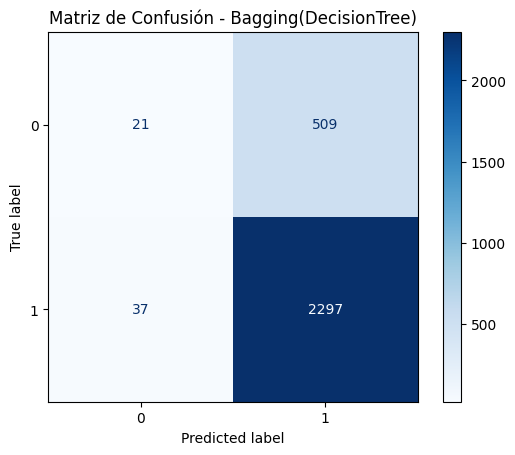

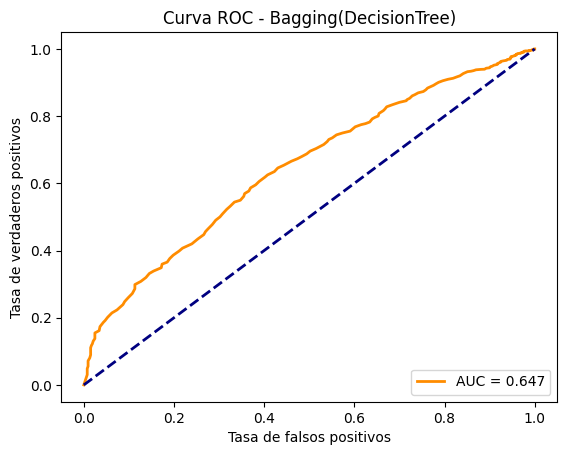

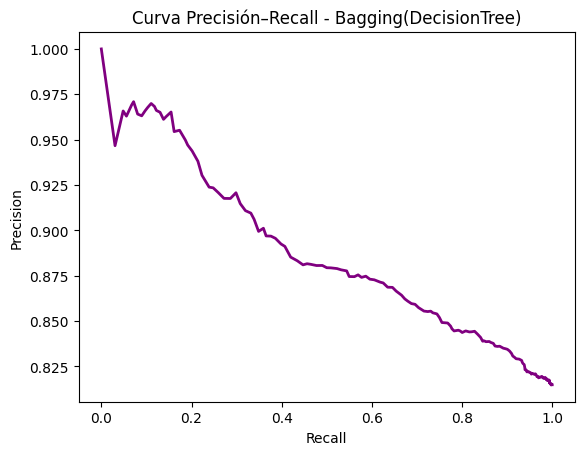

C:\Users\AnnetteCristinaNarva\AppData\Local\Temp\ipykernel_16920\2241993360.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


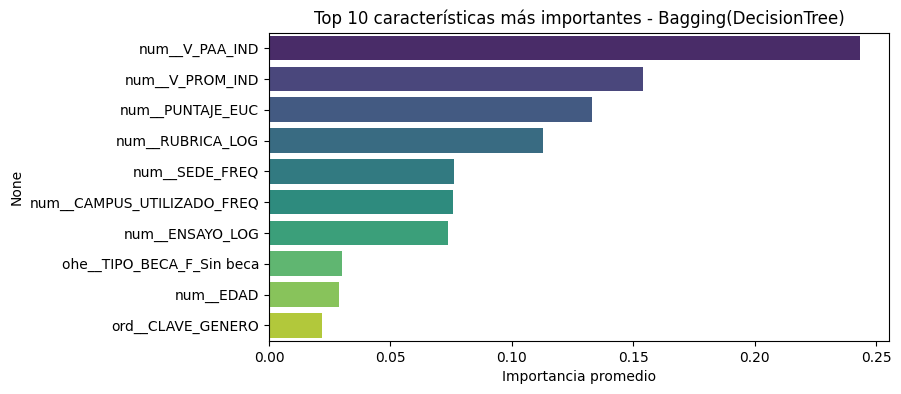

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
import numpy as np

# ========== 1. Entrenar modelo final ==========
final_model = bag_dt  # Tu Bagging(DecisionTree)
final_model.fit(X_train, y_train)

# Predicciones y probabilidades
y_pred = final_model.predict(X_test)
if hasattr(final_model, "predict_proba"):
    y_proba = final_model.predict_proba(X_test)[:, 1]
else:
    y_proba = None

# ========== 2. Matriz de Confusión ==========
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Bagging(DecisionTree)")
plt.show()

# ========== 3. Curva ROC ==========
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title("Curva ROC - Bagging(DecisionTree)")
    plt.legend(loc="lower right")
    plt.show()

# ========== 4. Curva Precisión–Recall ==========
if y_proba is not None:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(recall, precision, color="purple", lw=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curva Precisión–Recall - Bagging(DecisionTree)")
    plt.show()

# ========== 5. Importancia de características ==========
# (para Bagging, promediamos las importancias de los árboles base)
importances = np.mean([tree.feature_importances_ for tree in final_model.estimators_], axis=0)
indices = np.argsort(importances)[-10:][::-1]

plt.figure(figsize=(8,4))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Top 10 características más importantes - Bagging(DecisionTree)")
plt.xlabel("Importancia promedio")
plt.show()
